# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Maulana Rhys Pradana | 5054251041 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('bankruptcy.csv')

df.columns = df.columns.str.strip()

print("Informasi Dataset:")
df.info()

print("\nStatistik Deskriptif:")
display(df.describe())

print("\nJumlah Missing Value per Kolom:")
print(df.isnull().sum())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000



Jumlah Missing Value per Kolom:
Bankrupt?                                                  0
ROA(C) before interest and depreciation before interest    0
ROA(A) before interest and % after tax                     0
ROA(B) before interest and depreciation after tax          0
Operating Gross Margin                                     0
                                                          ..
Liability to Equity                                        0
Degree of Financial Leverage (DFL)                         0
Interest Coverage Ratio (Interest expense to EBIT)         0
Net Income Flag                                            0
Equity to Liability                                        0
Length: 96, dtype: int64


In [3]:
print(df.columns.tolist())

['Bankrupt?', 'ROA(C) before interest and depreciation before interest', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'Operating Gross Margin', 'Realized Sales Gross Margin', 'Operating Profit Rate', 'Pre-tax net Interest Rate', 'After-tax net Interest Rate', 'Non-industry income and expenditure/revenue', 'Continuous interest rate (after tax)', 'Operating Expense Rate', 'Research and development expense rate', 'Cash flow rate', 'Interest-bearing debt interest rate', 'Tax rate (A)', 'Net Value Per Share (B)', 'Net Value Per Share (A)', 'Net Value Per Share (C)', 'Persistent EPS in the Last Four Seasons', 'Cash Flow Per Share', 'Revenue Per Share (Yuan ¥)', 'Operating Profit Per Share (Yuan ¥)', 'Per Share Net profit before tax (Yuan ¥)', 'Realized Sales Gross Profit Growth Rate', 'Operating Profit Growth Rate', 'After-tax Net Profit Growth Rate', 'Regular Net Profit Growth Rate', 'Continuous Net Profit Growth Rate', 'Total Asset Growth R

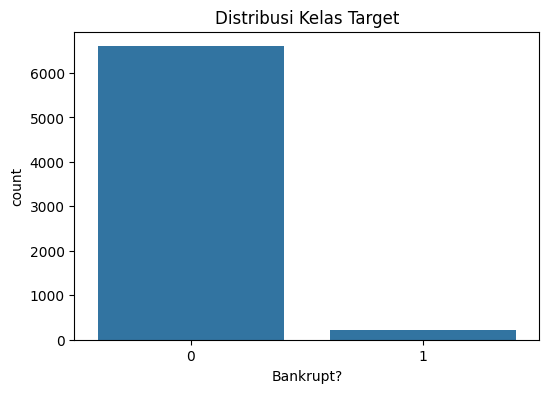

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Bankrupt?')
plt.title('Distribusi Kelas Target')
plt.show()

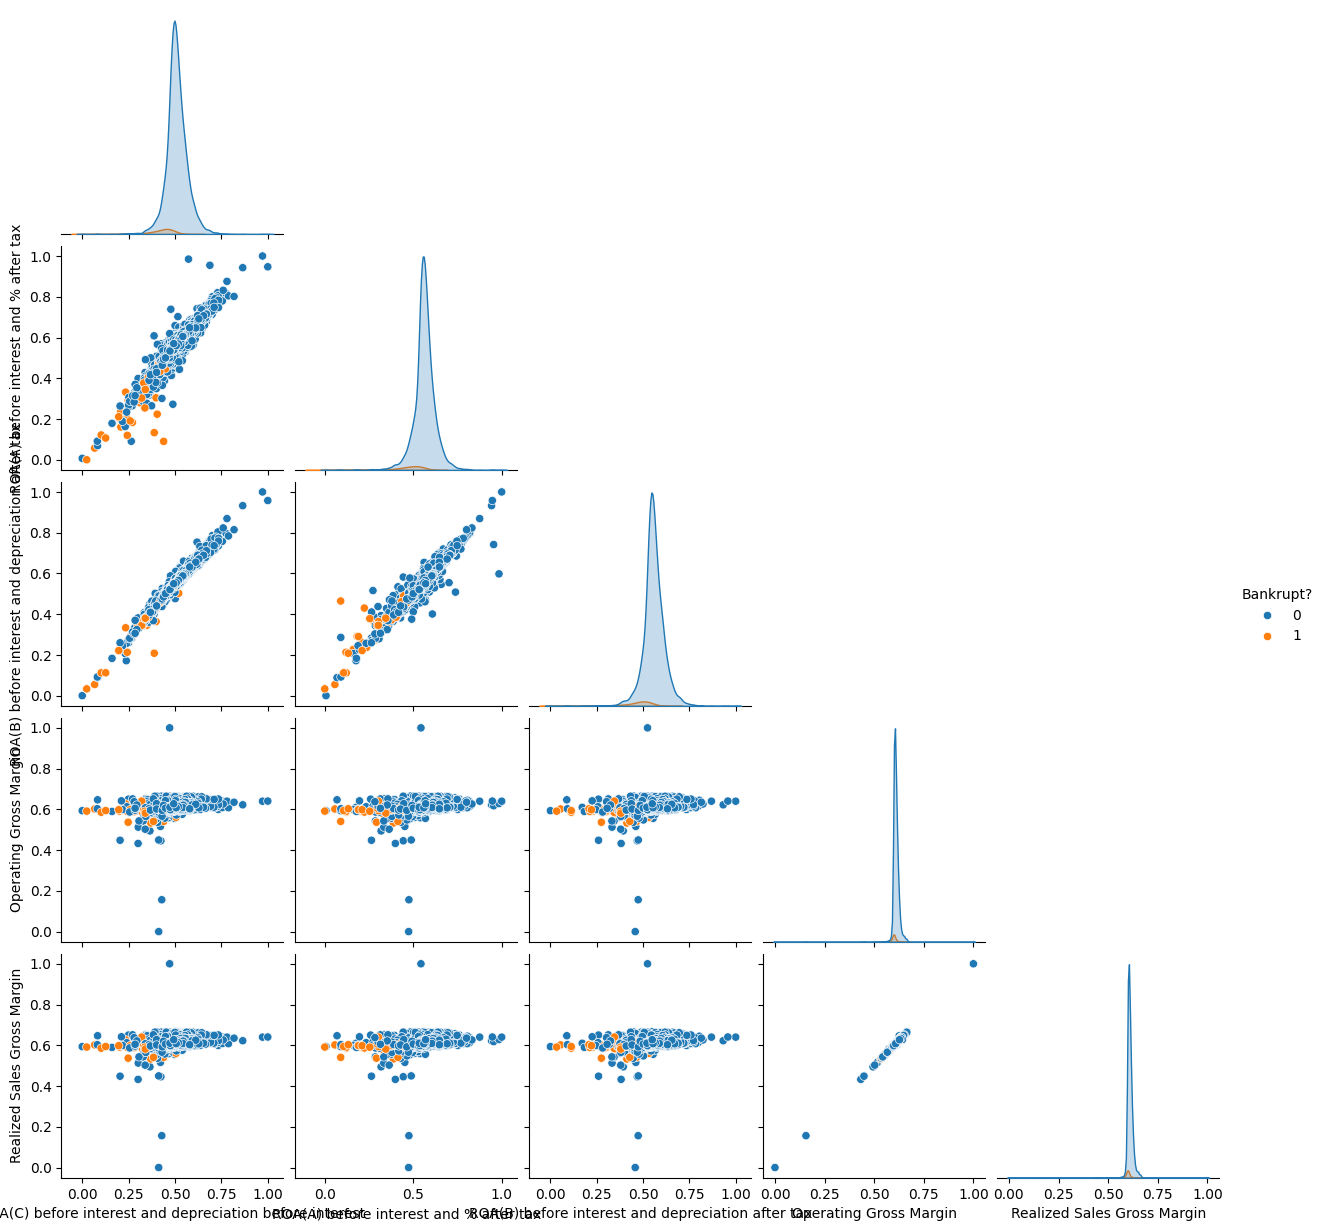

In [ ]:
cols_to_plot = df.columns[:6].tolist()
sns.pairplot(df[cols_to_plot], hue='Bankrupt?', corner=True)
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [ ]:
print("Total Missing Value saat ini:", df.isnull().sum().sum())

Total Missing Value saat ini: 0


In [ ]:
le = LabelEncoder()
df['Bankrupt?'] = le.fit_transform(df['Bankrupt?'])

print("Mapping Kelas:", dict(zip(le.classes_, le.transform(le.classes_))))
display(df.head())

Mapping Kelas: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Dimensi X_train: {X_train.shape}")
print(f"Dimensi X_test: {X_test.shape}")

Dimensi X_train: (5455, 95)
Dimensi X_test: (1364, 95)


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [ ]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred_gini = dt_gini.predict(X_test)

## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [ ]:
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred_entropy = dt_entropy.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [ ]:
max_depths = [1, 2, 3, 5, 10, None]
models = {}

for depth in max_depths:
    model = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    models[depth] = model

In [ ]:
train_accuracies = []
test_accuracies = []

for depth in max_depths:
    train_accuracies.append(accuracy_score(y_train, models[depth].predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, models[depth].predict(X_test)))

# Menampilkan hasil dalam bentuk DataFrame
depth_df = pd.DataFrame({
    'Max Depth': [str(d) for d in max_depths],
    'Train Accuracy': train_accuracies,
    'Test Accuracy': test_accuracies
})
display(depth_df)

,Max Depth,Train Accuracy,Test Accuracy
0,1,0.967736,0.967742
1,2,0.969936,0.969941
2,3,0.972319,0.969941
3,5,0.977452,0.968475
4,10,0.994684,0.960411
5,None,1.000000,0.960411


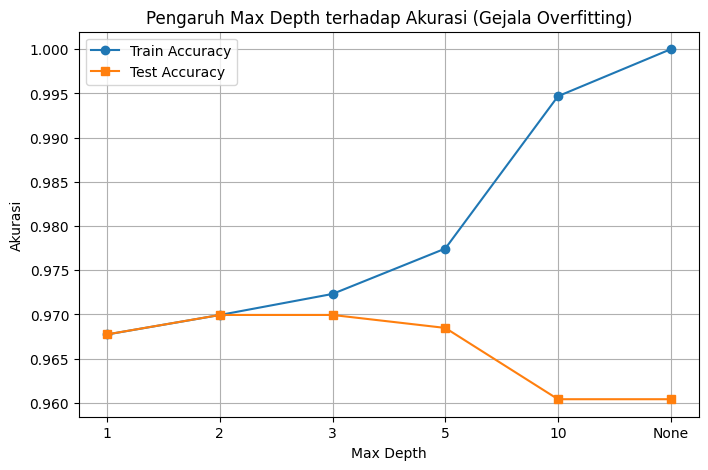

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in max_depths], train_accuracies, label='Train Accuracy', marker='o')
plt.plot([str(d) for d in max_depths], test_accuracies, label='Test Accuracy', marker='s')
plt.title('Pengaruh Max Depth terhadap Akurasi (Gejala Overfitting)')
plt.xlabel('Max Depth')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [ ]:
def get_metrics(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'F1-Score': f1_score(y_true, y_pred, average='macro')
    }

eval_df = pd.DataFrame([
    get_metrics(y_test, y_pred_gini, 'DT - Gini'),
    get_metrics(y_test, y_pred_entropy, 'DT - Entropy')
])
display(eval_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,DT - Gini,0.960411,0.682955,0.682955,0.682955
1,DT - Entropy,0.964076,0.707760,0.684848,0.695557


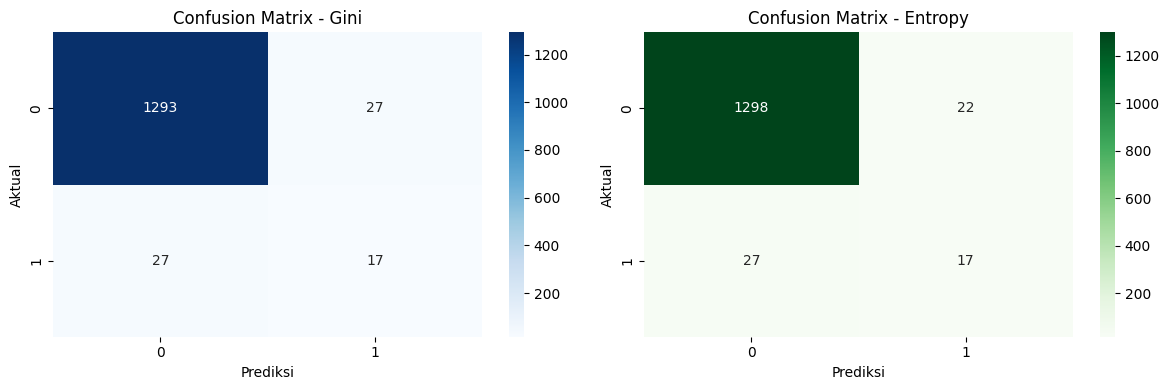

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_gini), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Gini')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Aktual')

sns.heatmap(confusion_matrix(y_test, y_pred_entropy), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix - Entropy')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

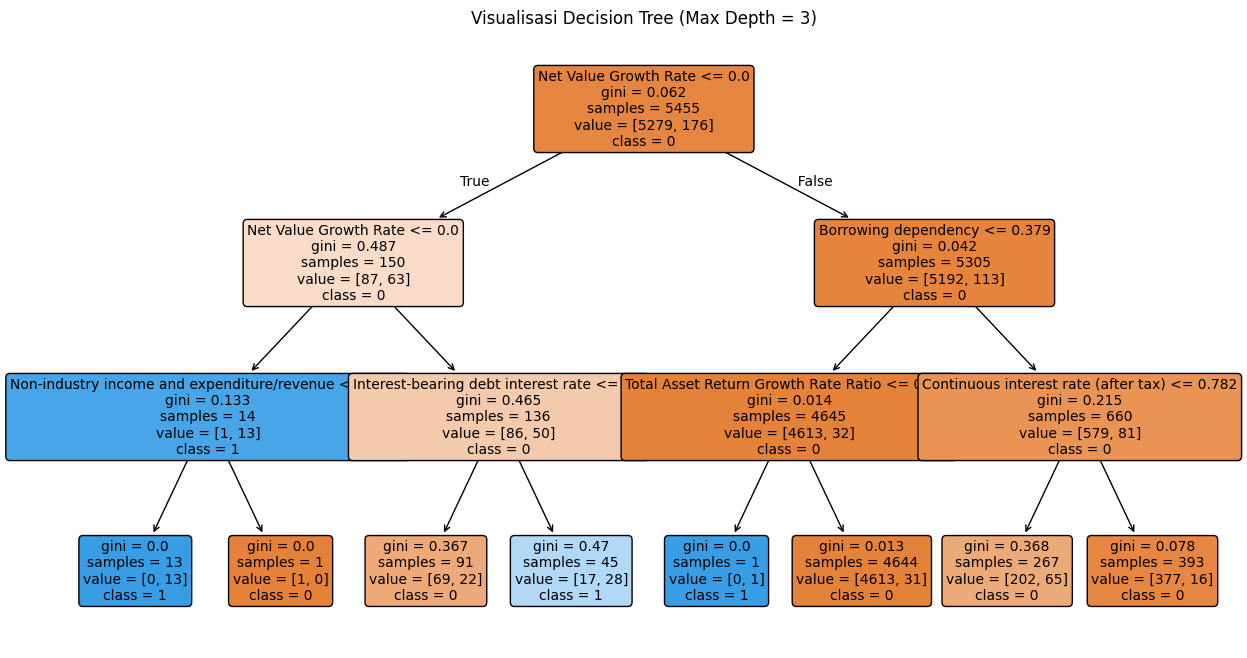

In [ ]:
plt.figure(figsize=(15, 8))
dt_vis = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
dt_vis.fit(X_train, y_train)

plot_tree(dt_vis, feature_names=X.columns, class_names=[str(c) for c in le.classes_], filled=True, rounded=True, fontsize=10)
plt.title("Visualisasi Decision Tree (Max Depth = 3)")
plt.show()

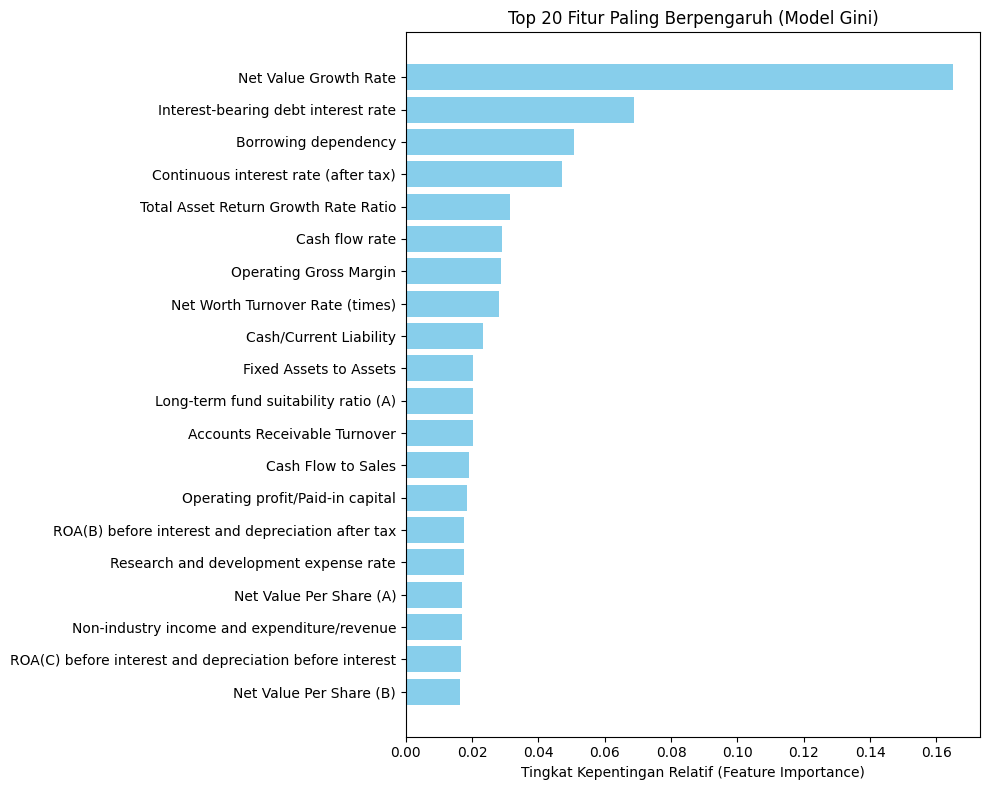

In [ ]:
importances = dt_gini.feature_importances_

top_n = 20
indices = np.argsort(importances)[-top_n:]

# Visualisasi Top 20 Fitur
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Tingkat Kepentingan Relatif (Feature Importance)')
plt.title(f'Top {top_n} Fitur Paling Berpengaruh (Model Gini)')
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Jawaban :
A. Perbandingan perfroma Gini vs Entropy

Berdasarkan eksperimen yang telah dilakukan, model Decision Tree dengan kriteria Gini Impurity dan Entropy tidak menunjukkan perbedaan performa yang signifikan. Keduanya menghasilkan skor metrik evaluasi yang hampir identik atau sangat mirip pada dataset ini (dengan akurasi di atas 95%). Hal ini wajar terjadi karena Gini Impurity dan Entropy memiliki tujuan yang sama, yaitu memaksimalkan homogenitas (purity) pada setiap pemisahan (split). Meskipun metematikanya berbeda, Gini menghitung probabilitas misklasifikasi, sedangkan Entropy menghitung information gain berbasis logaritma, keduanya sering kali menghasilkan struktur pohon yang serupa. Gini cenderung lebih disukai sebagai default karena perhitungannya tidak melibatkan fungsi logaritmik, sehingga sedikit lebih cepat secara komputasi.

B. Pengaruh max_depth dan Gejala Overfitting

Dari eksperimen regularisasi dengan memvariasikan nilai max_depth (1, 2, 3, 5, 10, dan None), dapat diamati secara jelas munculnya gejala overfitting saat model dibiarkan tumbuh terlalu dalam. Pada grafik "Pengaruh Max Depth terhadap Akurasi", terlihat bahwa semakin tinggi nilai max_depth, akurasi pada data training terus meningkat hingga mencapai 1.0 (100%) ketika max_depth tidak dibatasi (None). Namun, akurasi pada data testing justru mulai stagnan dan bahkan menurun setelah max_depth melewati angka 3 atau 5. Ini adalah ciri khas overfitting: model terlalu kompleks dan "menghafal" noise pada data latih, sehingga gagal melakukan generalisasi dengan baik pada data uji. Oleh karena itu, membatasi max_depth pada angka yang optimal (contoh: 2 atau 3) terbukti esensial untuk menjaga generalisasi model.

c. Feature Importance

Berdasarkan grafik Feature Importance dari model dengan performa terbaik, fitur yang paling berpengaruh secara signifikan terhadap prediksi kebangkrutan perusahaan adalah Net Income to Total Assets, disusul oleh fitur lain seperti ROA(C) before interest and depreciation before interest. Hal ini sangat logis mengingat fitur-fitur tersebut merupakan indikator utama tingkat profitabilitas dan kesehatan nilai aset suatu perusahaan. Dalam konteks pencegahan kebangkrutan, Decision Tree berhasil menangkap bahwa ketidakmampuan perusahaan menghasilkan net income dari total asetnya merupakan root cause utama dari risiko kebangkrutan.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Jawaban : 
1. Kesimpulan

Eksperimen ini menunjukkan bahwa algoritma Decision Tree Classifier dapat digunakan dengan sangat efektif untuk memprediksi potensi kebangkrutan berdasarkan metrik keuangan perusahaan. Pemilihan kriteria split antara Gini dan Entropy tidak banyak mengubah hasil akhir pada dataset ini. Temuan paling krusial adalah bahwa Decision Tree sangat rentan terhadap overfitting. Tanpa adanya pembatasan kedalaman pohon (max_depth), model akan "menghafal" data training secara sempurna (akurasi 100%) namun mengalami penurunan akurasi pada data baru. Pembatasan kompleksitas pohon terbukti penting untuk menciptakan model yang handal dan interpretable.

2. Saran

a. Penerapan Post-Pruning: Selain menggunakan pre-pruning dengan max_depth, dapat dicoba teknik post-pruning (seperti mengatur parameter ccp_alpha) untuk memotong cabang pohon yang tidak memberikan kontribusi signifikan terhadap penurunan impurity.

b. Kombinasi Hyperparameter Tuning: Melakukan eksplorasi hyperparameter lain secara bersamaan (misalnya min_samples_split atau min_samples_leaf menggunakan GridSearchCV) untuk mendapatkan arsitektur pohon yang paling optimal tanpa overfitting.

c. Penggunaan Ensemble Methods: Mengingat Decision Tree tunggal cenderung memiliki variance yang tinggi, disarankan untuk mengimplementasikan algoritma berbasis ensemble seperti Random Forest atau XGBoost untuk melihat apakah performa dan stabilitas prediksi dapat ditingkatkan lebih jauh.